<a href="https://colab.research.google.com/github/rubengamarro/practicas_aprendizaje_no_supervisado/blob/main/4_Redes_profundas_y_convolucionales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EJERCICIO 1

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()
df = pd.DataFrame(california.data,
columns=california.feature_names)
df['MedHouseVal'] = california.target # Columna objetivo

**Apartado a**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)
X_test_std_df = pd.DataFrame(X_test_std, columns=X_test.columns, index=X_test.index)

In [ ]:
X_train = torch.tensor(X_train_std, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test_std, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)
tam_lote = 8
train_loader = DataLoader(train_ds, tam_lote, shuffle=True)
test_loader = DataLoader(test_ds, tam_lote, shuffle=False)

**Apartado b**

In [ ]:
import torch
import torch.nn as nn

modelo_profundo_ReLU = nn.Sequential(
    nn.Linear(X_train.shape[1], 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)
modelo_profundo_ReLU

Sequential(
  (0): Linear(in_features=8, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=32, bias=True)
  (7): ReLU()
  (8): Linear(in_features=32, out_features=1, bias=True)
)

**Apartado c**

In [ ]:
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
def entrenar(modelo_red, num_epocas, ent_dataloader, X_valid, y_valid,
             func_perdida, metodo_optimiza, clasificacion=False):
  """
  Parámetros:
    ----------
    modelo_red : torch.nn.Module
        El modelo de red neuronal a entrenar.
    num_epocas : int
        Número de épocas para entrenar el modelo.
    ent_dataloader : torch.utils.data.DataLoader
        DataLoader que contiene los lotes del conjunto de entrenamiento.
    X_valid : torch.Tensor
        Tensor con los rasgos del conjunto de validación.
    y_valid : torch.Tensor
        Tensor con las salidas deseadas del conjunto de validación (vector)
    loss_fn : callable
        Función de pérdida utilizada para calcular la pérdida entre las
        predicciones y las salidas deseadas.
    metodo_optimiza : torch.optim.Optimizer
        Optimizador que actualiza los parámetros del modelo.
    clasificacion : bool, opcional (por defecto False)
        Si es True, calcula la exactitud además de la pérdida.

    Devuelve:
    -------
    loss_hist_ent : list[float]
        Lista con la pérdida promedio de entrenamiento por época.
    loss_hist_val : list[float]
        Lista con la pérdida promedio de validación por época.
    exact_hist_ent : list[float]
        Lista con la precisión promedio de entrenamiento por época (si clasificacion=True).
    exact_hist_val : list[float]
        Lista con la precisión promedio de validación por época (si clasificacion=True).
  """
  # Creamos listas para almacenar las métricas de entrenamiento y validación para cada época
  # 'loss' para la función de pérdida, 'exact' para la exactitud
  loss_hist_ent = [0] * num_epocas
  exact_hist_ent = [0] * num_epocas
  loss_hist_val = [0] * num_epocas
  exact_hist_val = [0] * num_epocas

  # Iniciamos el bucle de entrenamiento para todas las épocas
  for epoca in range(num_epocas):
    # Bucle a través de los lotes de entrenamiento (ent_dataloader)
    for x_lote, y_lote in ent_dataloader:
      # FORWARD #
      # Realizamos la predicción en el lote actual
      pred = modelo_red(x_lote)
      # Si la salida predicha es un vector  (una única neurona de salida)

      # Calculamos la pérdida (loss) usando la función de pérdida especificada
      loss = func_perdida(pred, y_lote)

      # BACKWARD
      loss.backward()
      metodo_optimiza.step()
      metodo_optimiza.zero_grad()

      # RENDIMIENTOS en entrenamiento
      # Acumulamos la pérdida media del entrenamiento para este lote
      loss_hist_ent[epoca] += loss.item()

      if clasificacion:
        if pred.dim()==1:  # 1 neurona => clasificación binaria
          if isinstance(func_perdida, nn.BCELoss): # Para BCELoss, con sigmoide explícita
            clase_pred = (pred >= 0.5).float()
          else:  # Para BCELossWithLogits, sin sigmoide explícita, la salida es un logit
            clase_pred = (pred >= 0.0).float()
        else:  # Varias neuronas de salida => dos o más neuronas de salida
          clase_pred = torch.argmax(pred, dim=1)
        correcto = (clase_pred == y_lote).float()
        # Calculamos exactitud media de entrenamiento del lote
        exact_hist_ent[epoca] += correcto.mean().item()

    # Promediamos la pérdida y la precisión de entrenamiento para toda la
    # época dividiendo por el número de lotes
    loss_hist_ent[epoca] /= len(ent_dataloader)
    if clasificacion:
      exact_hist_ent[epoca] /= len(ent_dataloader)

    # RENDIMIENTOS en validación
    with torch.no_grad():
      pred = modelo_red(X_valid)
      loss = func_perdida(pred, y_valid)

      # Almacenamos la pérdida media en validación
      loss_hist_val[epoca] = loss.item()
      # Si es un problema de clasificación => calculamos exactitudes
      if clasificacion:
        if pred.dim()==1: # Binaria
          if isinstance(func_perdida, nn.BCELoss): # Para BCELoss, con sigmoide explícita
            clase_pred = (pred >= 0.5).float()
          else:  # Para BCELossWithLogits, sin sigmoide explícita, la salida es un logit
            clase_pred = (pred >= 0.0).float()
        else:             # Multiclase
          clase_pred = torch.argmax(pred, dim=1)
        correcto = (clase_pred == y_valid).float()
        # Almacenamos la exactitud media en validación
        exact_hist_val[epoca] = correcto.mean().item()

    # Imprimir métricas cada cierto número de épocas (opcional)
    if (epoca + 1) % 10 == 0:
      print(f"Época {epoca + 1}/{num_epocas} | Pérdida Entrenamiento: {loss_hist_ent[epoca]:.4f} | "
            f"Pérdida Validación: {loss_hist_val[epoca]:.4f} | "
            f"Exactitud Entrenamiento: {exact_hist_ent[epoca]:.4f} | "
            f"Exactitud Validación: {exact_hist_val[epoca]:.4f}")

  # Retornamos las métricas de pérdida y precisión para el entrenamiento y la validación
  return loss_hist_ent, loss_hist_val, exact_hist_ent, exact_hist_val

In [ ]:
def dibujar_rendimientos(historico_rendimientos):
    fig = plt.figure(figsize=(16, 4))
    ax = fig.add_subplot(1, 2, 1)
    plt.plot(historico_rendimientos[0], lw=4)
    plt.plot(historico_rendimientos[1], lw=4)
    plt.legend(['Pérdida ent.', 'Pérdida val.'], fontsize=15)
    plt.title("Pérdida")
    ax.set_xlabel('Épocas', size=15)
    ax = fig.add_subplot(1, 2, 2)
    plt.plot(historico_rendimientos[2], lw=4)
    plt.plot(historico_rendimientos[3], lw=4)
    plt.legend(['Exactitud ent.', 'Exactitud val.'], fontsize=15)
    plt.title("Exactitud")
    ax.set_xlabel('Épocas', size=15)

In [ ]:
# Configuración del optimizador y la función de pérdida
func_perdida = nn.MSELoss()
optimizador = torch.optim.Adam(modelo_profundo_ReLU.parameters(), lr=0.001)

In [ ]:
torch.manual_seed(42)
historico = entrenar(
    modelo_profundo_ReLU, 50,
    train_loader,
    X_test,
    y_test,
    func_perdida,
    optimizador,
    False
)

Época 10/50 | Pérdida Entrenamiento: 0.2743 | Pérdida Validación: 0.2947 | Exactitud Entrenamiento: 0.0000 | Exactitud Validación: 0.0000
Época 20/50 | Pérdida Entrenamiento: 0.2434 | Pérdida Validación: 0.2622 | Exactitud Entrenamiento: 0.0000 | Exactitud Validación: 0.0000
Época 30/50 | Pérdida Entrenamiento: 0.2197 | Pérdida Validación: 0.2617 | Exactitud Entrenamiento: 0.0000 | Exactitud Validación: 0.0000
Época 40/50 | Pérdida Entrenamiento: 0.1991 | Pérdida Validación: 0.2512 | Exactitud Entrenamiento: 0.0000 | Exactitud Validación: 0.0000
Época 50/50 | Pérdida Entrenamiento: 0.1827 | Pérdida Validación: 0.2945 | Exactitud Entrenamiento: 0.0000 | Exactitud Validación: 0.0000


**Apartado d**

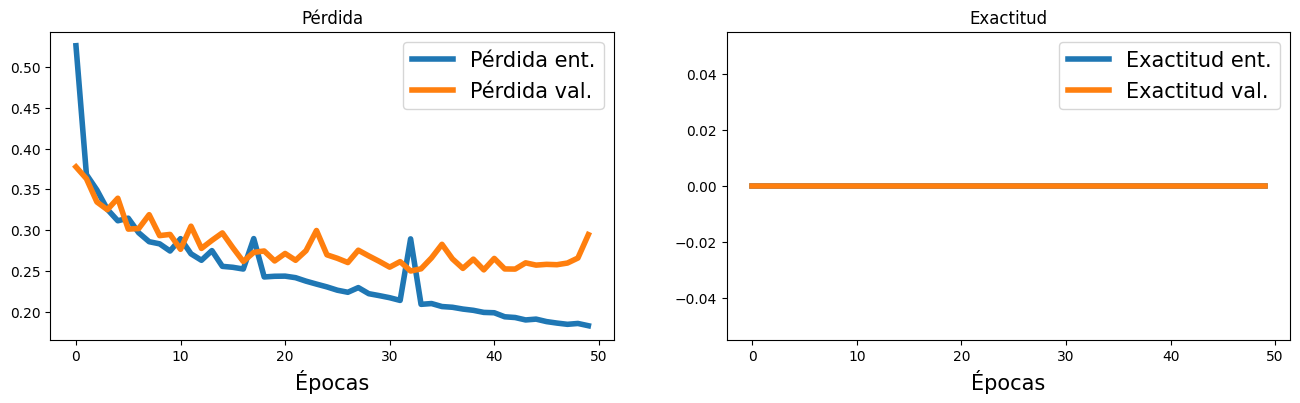

In [ ]:
dibujar_rendimientos(historico)

**Apartado e**

Creo que si podría haber un poco de sobreajuste, ya que la pérdida en entrenamiento disminuye al aumentar el número de épocas, mientras que la pérdida en validación se estanca e incluso comienza a aumentar alrededor de las 40-50 épocas. Podríamos aplicar algunas técnicas como la desactivación, desactivando algunas neuronas de las capas ocultas.

**Apartado f**

In [ ]:
from sklearn.metrics import r2_score

with torch.no_grad():
    y_pred = modelo_profundo_ReLU(X_test)

r2 = r2_score(y_test.numpy(), y_pred.numpy())

print(f"Coeficiente de determinación: {r2:.4f}")


Coeficiente de determinación: 0.7753


#EJERCICIO 2

In [ ]:
from sklearn.datasets import fetch_covtype
data = fetch_covtype()
X, y = data.data, data.target - 1 # Ajustar etiquetas para que comiencen en 0

**Apartado a**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

**Apartado b**

In [ ]:
X_train = torch.tensor(X_train_std, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test_std, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

tam_lote = 1024
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, tam_lote, shuffle=True)
test_loader = DataLoader(test_ds, tam_lote, shuffle=False)

In [ ]:
# Configuración del dispositivo
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo disponible: {dispositivo}")

Dispositivo disponible: cuda


In [ ]:
torch.manual_seed(42)
modelo_profundo_clasificacion = nn.Sequential(
    nn.Linear(X_train.shape[1], 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 7)
).to(dispositivo)
modelo_profundo_clasificacion

Sequential(
  (0): Linear(in_features=54, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=128, bias=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=64, bias=True)
  (10): ReLU()
  (11): Linear(in_features=64, out_features=7, bias=True)
)

In [ ]:
def entrenarGPU(modelo, num_epocas, ent_dl, val_dl, func_perd, optimiz, disposit):
    # Inicializamos listas para guardar los históricos de pérdida y exactitud por época
    loss_hist_ent = [0] * num_epocas
    loss_hist_val = [0] * num_epocas
    exact_hist_ent = [0] * num_epocas
    exact_hist_val = [0] * num_epocas

    # Iteramos sobre el número total de épocas
    for epoca in range(num_epocas):
        modelo.train()  # Ponemos el modelo en modo de entrenamiento,
                        # OjO, activa dropout

        # Iteramos sobre los lotes del DataLoader de entrenamiento
        for x_lote, y_lote in ent_dl:
            # Movemos las muestras al dispositivo especificado (CPU/GPU)
            x_lote, y_lote = x_lote.to(disposit), y_lote.to(disposit)

            # Hacemos una predicción con el modelo
            pred = modelo(x_lote)

            # Calculamos la pérdida utilizando la función de pérdida proporcionada
            # y propagamos error
            loss = func_perd(pred, y_lote)
            loss.backward()

            # Actualizamos los pesos del modelo
            optimiz.step()
            optimiz.zero_grad()

            # Acumulamos la pérdida total
            loss_hist_ent[epoca] += loss.item()

            # Calculamos la cantidad de predicciones correctas
            correcto_ent = (torch.argmax(pred, dim=1) == y_lote).float()

            # Acumulamos las predicciones correctas
            exact_hist_ent[epoca] += correcto_ent.mean().cpu()

        # Normalizamos rendimientos acumulados dividiendo por número de lotes
        loss_hist_ent[epoca] /= len(ent_dl)
        exact_hist_ent[epoca] /= len(ent_dl)

        modelo.eval()  # Ponemos el modelo en modo de evaluación,
                       # OjO, desactiva dropout
        with torch.no_grad():  # Desactivamos el cálculo de gradientes
            # Iteramos sobre los lotes del DataLoader de validación
            for x_lote, y_lote in val_dl:
                x_lote, y_lote = x_lote.to(disposit), y_lote.to(disposit)

                pred = modelo(x_lote)
                loss = func_perd(pred, y_lote)

                # Acumulamos rendimientos
                loss_hist_val[epoca] += loss.item()
                correcto_val = (torch.argmax(pred, dim=1) == y_lote).float()
                exact_hist_val[epoca] += correcto_val.mean().cpu()

        # Normalizamos las pérdidas y la exactitud acumuladas dividiendo
        # por el número de lotes
        loss_hist_val[epoca] /= len(val_dl)
        exact_hist_val[epoca] /= len(val_dl)

        # Imprimimos las estadísticas de la época actual
        print(f'Época: {epoca + 1}/{num_epocas}, '
              f'Exactitud ent.: {exact_hist_ent[epoca]:.4f}, '
              f'Exactitud val.: {exact_hist_val[epoca]:.4f}')

    return loss_hist_ent, loss_hist_val, exact_hist_ent, exact_hist_val

In [ ]:
func_perdida_clasificacion = nn.CrossEntropyLoss()
optimizador_clasificacion = torch.optim.Adam(modelo_profundo_clasificacion.parameters(), lr=0.001)

historico_clasificacion = entrenarGPU(
    modelo_profundo_clasificacion, 50,
    train_loader,
    test_loader,
    func_perdida_clasificacion,
    optimizador_clasificacion,
    dispositivo
)

Época: 1/50, Exactitud ent.: 0.7115, Exactitud val.: 0.7603
Época: 2/50, Exactitud ent.: 0.7622, Exactitud val.: 0.7890
Época: 3/50, Exactitud ent.: 0.7838, Exactitud val.: 0.8133
Época: 4/50, Exactitud ent.: 0.7997, Exactitud val.: 0.8305
Época: 5/50, Exactitud ent.: 0.8111, Exactitud val.: 0.8370
Época: 6/50, Exactitud ent.: 0.8204, Exactitud val.: 0.8495
Época: 7/50, Exactitud ent.: 0.8281, Exactitud val.: 0.8606
Época: 8/50, Exactitud ent.: 0.8349, Exactitud val.: 0.8663
Época: 9/50, Exactitud ent.: 0.8400, Exactitud val.: 0.8733
Época: 10/50, Exactitud ent.: 0.8447, Exactitud val.: 0.8772
Época: 11/50, Exactitud ent.: 0.8489, Exactitud val.: 0.8800
Época: 12/50, Exactitud ent.: 0.8519, Exactitud val.: 0.8837
Época: 13/50, Exactitud ent.: 0.8544, Exactitud val.: 0.8865
Época: 14/50, Exactitud ent.: 0.8571, Exactitud val.: 0.8902
Época: 15/50, Exactitud ent.: 0.8606, Exactitud val.: 0.8917
Época: 16/50, Exactitud ent.: 0.8629, Exactitud val.: 0.8954
Época: 17/50, Exactitud ent.: 0.8

**Apartado c**

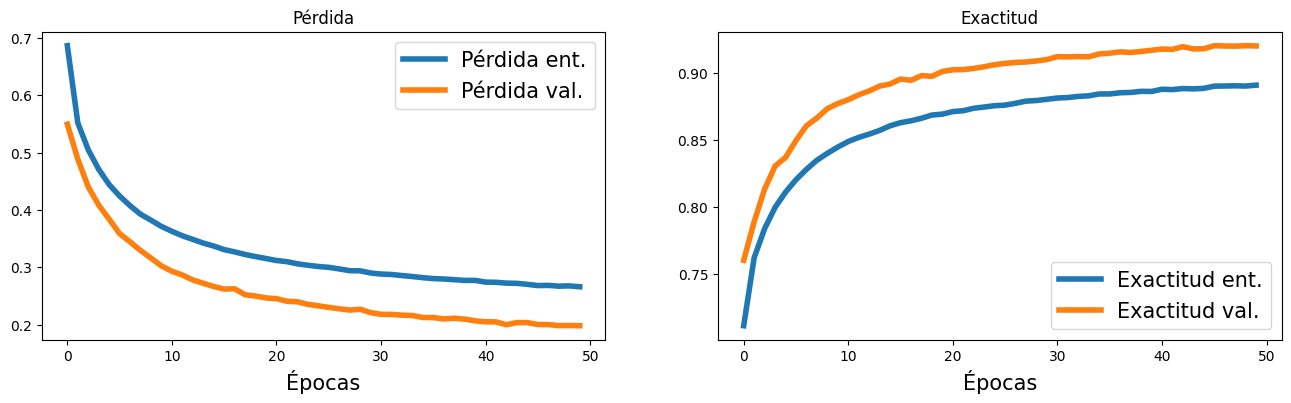

In [ ]:
dibujar_rendimientos(historico_clasificacion)

**Apartado d**

No, ya que las redes neuronales convolucionales están diseñadas para datos en forma de imagen o cuadrícula. Nuestros datos no tienen esa estructura espacial, ya que el orden de las columnas es aribitrario, luego no están diseñados para ser procesados por una CNN.

#EJERCICIO 3

**Apartado a**

In [ ]:
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Preparación de los datos
transformacion = transforms.Compose([
    transforms.ToTensor()
])

ruta_archivos = './Imagenes'
train_dataset = datasets.CIFAR10(root=ruta_archivos, train=True, download=True, transform=transformacion)
test_dataset = datasets.CIFAR10(root=ruta_archivos, train=False, download=True, transform=transformacion)

torch.manual_seed(1)
ent_dl = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dl = DataLoader(test_dataset, batch_size=64, shuffle=False)

**Apartado b**

In [ ]:
# Configuración del dispositivo
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Definición del modelo usando Sequential
modelo = nn.Sequential(
    # Bloque 1: Convolución + ReLU
    # 3 canales de entrada, 35 mapas de salida [32x32]
    nn.Conv2d(3, 35, kernel_size=3, padding=1),
    nn.ReLU(),

    # Bloque 2: Convolución + ReLU + MaxPool
    # 35 mapas de entrada, 65 mapas de salida [32x32]
    nn.Conv2d(35, 65, kernel_size=3, padding=1),
    nn.ReLU(),
    # Resultado submuestreo: 65 mapas [16x16]
    nn.MaxPool2d(kernel_size=2, stride=2),

    # Aplanado
    # 65 mapas [16x16] = 65 * 16 * 16 estímulos
    nn.Flatten(),

    # Bloque 3: Capa oculta + ReLU + Dropout
    # 65 * 16 * 16 estímulos, 512 neuronas ReLu
    nn.Linear(65 * 16 * 16, 512),
    nn.ReLU(),
    nn.Dropout(0.5),

    # Capa de salida con puntuaciones de clase
    # 512 estímulos, 10 clases => 10 puntuaciones de clase
    nn.Linear(512, 10)
).to(dispositivo)